In [6]:
from sklearn.ensemble import RandomForestClassifier
import cv2 as cv
import numpy as np
import os
import matplotlib.pyplot as plt
from keras.layers import Input, Dense, Conv2D, MaxPool2D, GlobalAveragePooling2D
from keras.models import Sequential, Model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import tensorflow as tf

### setup our data

In [7]:
i = 0
train_dr = '/kaggle/input/datasets/t2obd1a1253kmit/clean-augmented-anemia-dataset/New_Augmented_Anemia_Dataset/Conjuctiva/Training'
valid_dr = '/kaggle/input/datasets/t2obd1a1253kmit/clean-augmented-anemia-dataset/New_Augmented_Anemia_Dataset/Conjuctiva/Validation'
anemia_data_dir = '/kaggle/input/datasets/t2obd1a1253kmit/clean-augmented-anemia-dataset/New_Augmented_Anemia_Dataset/Conjuctiva/Training/Anemic'
for item in os.listdir(anemia_data_dir) :
    i +=1
print(f"number of training data is {i}")
i = 0
non_anemia_data_dir = '/kaggle/input/datasets/t2obd1a1253kmit/clean-augmented-anemia-dataset/New_Augmented_Anemia_Dataset/Conjuctiva/Training/Non-Anemic'
i = 0
for item in os.listdir(non_anemia_data_dir) :
    i +=1
print(f"number of training non anemic data is {i}")

number of training data is 4219
number of training non anemic data is 4037


In [8]:
## viz images :
from tensorflow.keras.preprocessing.image import load_img
img = "/kaggle/input/datasets/t2obd1a1253kmit/clean-augmented-anemia-dataset/New_Augmented_Anemia_Dataset/Finger_Nails/Training/Anemic/Anemic-FN-001_aug1.png"
img_1 = load_img(img)
img_1.size

(224, 224)

### Load our data (using ImageDataGenerator) and  , rescale it

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
datagen = ImageDataGenerator(
    rescale=1./255,  # Normalize pixel values to [0, 1]
    rotation_range=20,  # Rotate images by 20 degrees
    width_shift_range=0.2,  # Shift images horizontally by 20% of the width
    height_shift_range=0.2,  # Shift images vertically by 20% of the height
    shear_range=0.2,  # Shear intensity (shear angle in radians)
    zoom_range=0.2,  # Zoom range [1-zoom_range, 1+zoom_range]
    horizontal_flip=True,  # Flip images horizontally
    fill_mode='nearest'  # Fill mode for filling in newly created pixels
)

### resize the images

In [10]:
train_generator = datagen.flow_from_directory(
    train_dr,
    target_size=(128, 128),  # ← changed from 64
    batch_size=32,
    class_mode='binary'
)

valid_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
    valid_dr,
    target_size=(128, 128),  # ← changed from 64
    batch_size=32,
    class_mode='binary'
)

Found 8256 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


### test our result

In [11]:
for item in train_generator : 
    print(item[1].shape)
    break

(32,)


### build model architacteur

In [12]:
from tensorflow.keras import layers
from tensorflow.keras.layers import Input
from keras.models import Sequential, Model
from keras.layers import Input, Dense, Conv2D, MaxPool2D, GlobalAveragePooling2D, Dropout, BatchNormalization

inputs = Input(shape=(128, 128, 3))

# Block 1
x1 = Conv2D(32, (3,3), padding="same", activation="relu")(inputs)
x1 = BatchNormalization()(x1)
x2 = MaxPool2D(2,2)(x1)

# Block 2
x3 = Conv2D(64, (3,3), padding="same", activation="relu")(x2)
x3 = BatchNormalization()(x3)
x4 = MaxPool2D(2,2)(x3)

# Block 3
x5 = Conv2D(128, (3,3), padding="same", activation="relu")(x4)
x5 = BatchNormalization()(x5)
x6 = MaxPool2D(2,2)(x5)

# Block 4 — extra depth
x7 = Conv2D(256, (3,3), padding="same", activation="relu")(x6)
x7 = BatchNormalization()(x7)
x8 = MaxPool2D(2,2)(x7)

# Head
x9  = GlobalAveragePooling2D()(x8)
x10 = Dropout(0.4)(x9)
x11 = Dense(128, activation="relu")(x10)
x12 = Dropout(0.3)(x11)
x13 = Dense(1, activation="sigmoid")(x12)

model = Model(inputs=inputs, outputs=x13)
model.summary()

I0000 00:00:1777122956.669235      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777122956.675234      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,361 (1.61 MB)

 Trainable params: 422,401 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [13]:
model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(),
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

In [14]:
history = model.fit(train_generator,validation_data=valid_generator, epochs=100)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100


I0000 00:00:1777122963.137729     154 service.cc:152] XLA service 0x79cb7c0594b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777122963.137767     154 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777122963.137770     154 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777122963.914222     154 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/258 ━━━━━━━━━━━━━━━━━━━━ 46:44 11s/step - accuracy: 0.5625 - loss: 0.7656 - precision: 0.6000 - recall: 0.7895

I0000 00:00:1777122970.157324     154 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


258/258 ━━━━━━━━━━━━━━━━━━━━ 143s 515ms/step - accuracy: 0.5540 - loss: 0.7082 - precision: 0.5438 - recall: 0.5543 - val_accuracy: 0.5000 - val_loss: 2.5285 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 57s 222ms/step - accuracy: 0.6192 - loss: 0.6520 - precision: 0.5999 - recall: 0.7019 - val_accuracy: 0.5840 - val_loss: 0.7159 - val_precision: 0.5727 - val_recall: 0.6620
Epoch 3/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 53s 204ms/step - accuracy: 0.6340 - loss: 0.6360 - precision: 0.6031 - recall: 0.7418 - val_accuracy: 0.5330 - val_loss: 0.7158 - val_precision: 0.5171 - val_recall: 1.0000
Epoch 4/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 53s 206ms/step - accuracy: 0.6375 - loss: 0.6297 - precision: 0.6105 - recall: 0.7175 - val_accuracy: 0.6570 - val_loss: 0.6091 - val_precision: 0.7127 - val_recall: 0.5260
Epoch 5/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 57s 222ms/step - accuracy: 0.6409 - loss: 0.6202 - precision: 0.6036 - recall: 0.7173 - val_accuracy: 0.67

### save the model to use it

In [15]:
model.save('model_anemia.keras')

In [16]:
# ── Guaranteed download ──
from IPython.display import FileLink, display
import os

print("✅ Model saved successfully!")
print(f"📁 Location: /kaggle/working/model_anemia.h5")
print(f"📦 Size: {os.path.getsize('/kaggle/working/model_anemia.keras') / 1024 / 1024:.1f} MB")
display(FileLink('/kaggle/working/model_anemia.keras'))

✅ Model saved successfully!
📁 Location: /kaggle/working/model_anemia.h5
📦 Size: 4.9 MB


/kaggle/working/model_anemia.keras

In [17]:
import os
files = os.listdir('/kaggle/working/')
print(files)

['model_anemia.keras', '.virtual_documents']


### see our results

In [18]:
import pandas as pd
model_information = pd.DataFrame(history.history)
model_information

,accuracy,loss,precision,recall,val_accuracy,val_loss,val_precision,val_recall
0,0.577762,0.680389,0.563261,0.607629,0.500,2.528524,0.000000,0.000
1,0.620397,0.648796,0.594004,0.706713,0.584,0.715897,0.572664,0.662
2,0.630329,0.636463,0.599115,0.737429,0.533,0.715843,0.517063,1.000
3,0.640019,0.623868,0.609500,0.734209,0.657,0.609060,0.712737,0.526
4,0.644622,0.618975,0.612804,0.742135,0.673,0.630547,0.630862,0.834
...,...,...,...,...,...,...,...,...
95,0.953731,0.126102,0.953361,0.951945,0.991,0.033276,0.986139,0.996
96,0.954215,0.122491,0.953183,0.953183,0.922,0.191935,0.899621,0.950
97,0.955305,0.121446,0.954861,0.953678,0.892,0.320500,0.945455,0.832
98,0.954336,0.121550,0.952075,0.954669,0.979,0.056595,0.974257,0.984


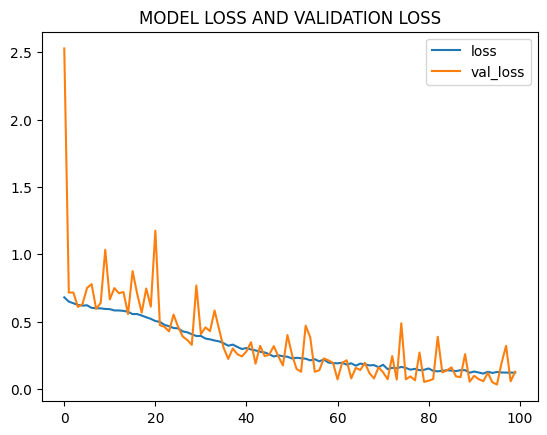

In [19]:
"""VISULIZE MODEL """
plt.plot(np.arange(100) , model_information['loss'] , label="loss")
plt.plot(np.arange(100) , model_information['val_loss'] , label="val_loss")
plt.title('MODEL LOSS AND VALIDATION LOSS')
plt.savefig('MOBILE_pretrained_loss.png')
plt.legend()
plt.show()

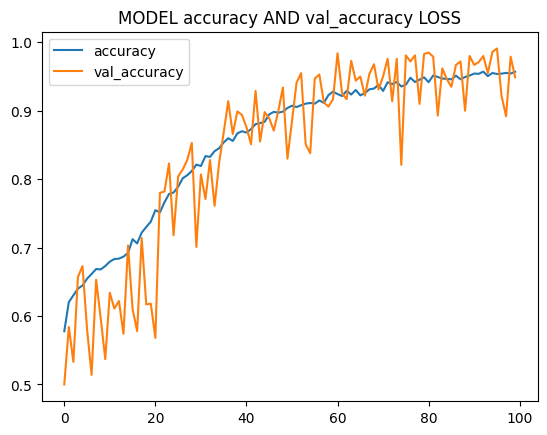

In [20]:
"""VISULIZE MODEL """
plt.plot(np.arange(100) , model_information['accuracy'] , label="accuracy")
plt.plot(np.arange(100) , model_information['val_accuracy'] , label="val_accuracy")
plt.title('MODEL accuracy AND val_accuracy LOSS')
plt.savefig('MOBILE_pretrained_val_accuracy.png')
plt.legend()
plt.show()

In [21]:
###test data
import os
test_images = []
test_data  = "/kaggle/input/datasets/t2obd1a1253kmit/clean-augmented-anemia-dataset/New_Augmented_Anemia_Dataset/Conjuctiva/Testing"
for item in os.listdir(test_data) :
      for img in os.listdir(os.path.join(test_data , item)) :
        test_images.append([os.path.join(test_data ,item , img ), item])

In [22]:
import random
random.shuffle(test_images)

In [23]:
test = test_images[0]
img = test[0]
label = test[1]

In [24]:
label

'Anemic'

In [25]:
class_names = train_generator.class_indices
classes = list(class_names.keys())
classes

['Anemic', 'Non-Anemic']

### evaluation

In [26]:
test_data_eval = model.evaluate(valid_generator)

32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - accuracy: 0.9457 - loss: 0.1162 - precision: 0.9612 - recall: 0.9289


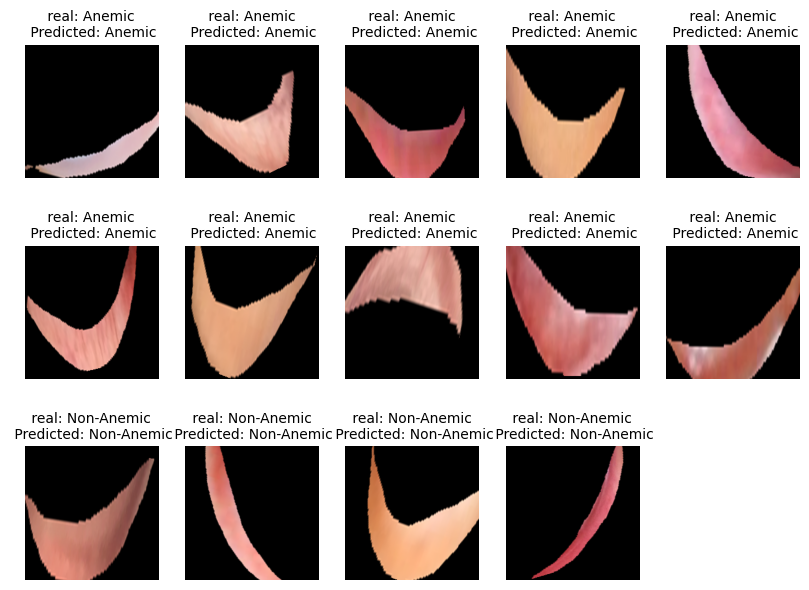

In [27]:
#TEST VISULIZATION
from tensorflow.keras.preprocessing import image
def preprocess_image(img_path):
    img = image.load_img(img_path, target_size=(128, 128))  # Assuming your model expects 64x64 images
    img = image.img_to_array(img)
    img = img /255.0
    img = np.expand_dims(img, axis=0)
    return img

# Function to predict class and visualize the image
def predict_and_visualize(image_paths):
    plt.figure(figsize=(10, 10))
    for i, img_path in enumerate(image_paths):
        img = preprocess_image(img_path[0])
        prediction = model.predict(img , verbose=0)
        
        predicted_class = classes[int(prediction.round()[0][0])]

        # Load and display the image
        plt.subplot(4, 5, i+1)
        plt.imshow(image.load_img(img_path[0]))
        plt.title(f' real: {img_path[1]} \n Predicted: {predicted_class}' , fontsize=10 )
        plt.axis('off')
    plt.savefig('result.png')
    plt.show()
    
predict_and_visualize(test_images[:14])

In [28]:
# ── Confidence Score for each prediction ──
print("\n── Confidence Scores ──")
for i, img_path in enumerate(test_images[:14]):
    img = preprocess_image(img_path[0])
    prediction = model.predict(img, verbose=0)
    score = float(prediction[0][0])
    predicted_class = classes[int(round(score))]
    real_class = img_path[1]
    confidence = score if predicted_class == 'Non-Anemic' else 1 - score
    print(f"Image {i+1:2d} | Real: {real_class:12s} | Predicted: {predicted_class:12s} | Confidence: {confidence:.4f} ({confidence*100:.1f}%)")


── Confidence Scores ──
Image  1 | Real: Anemic       | Predicted: Anemic       | Confidence: 0.9976 (99.8%)
Image  2 | Real: Anemic       | Predicted: Anemic       | Confidence: 0.8926 (89.3%)
Image  3 | Real: Anemic       | Predicted: Anemic       | Confidence: 1.0000 (100.0%)
Image  4 | Real: Anemic       | Predicted: Anemic       | Confidence: 1.0000 (100.0%)
Image  5 | Real: Anemic       | Predicted: Anemic       | Confidence: 0.9967 (99.7%)
Image  6 | Real: Anemic       | Predicted: Anemic       | Confidence: 1.0000 (100.0%)
Image  7 | Real: Anemic       | Predicted: Anemic       | Confidence: 1.0000 (100.0%)
Image  8 | Real: Anemic       | Predicted: Anemic       | Confidence: 1.0000 (100.0%)
Image  9 | Real: Anemic       | Predicted: Anemic       | Confidence: 1.0000 (100.0%)
Image 10 | Real: Anemic       | Predicted: Anemic       | Confidence: 1.0000 (100.0%)
Image 11 | Real: Non-Anemic   | Predicted: Non-Anemic   | Confidence: 0.9997 (100.0%)
Image 12 | Real: Non-Anemic   | 